In [1]:
from pyscf import gto, scf
import numpy as np

# ──────────────────────────────────────────────────────────────
# 1.  LiFSI: Li+  +  N(SO2F)2–  (C1 symmetry, rough gas‑phase structure)
#     • Central N‑atom bound to two SO2F groups
#     • Li+ placed ~2.2 Å from the imide N along +z
#     (Geometry can be replaced with an optimized structure later.)
# ──────────────────────────────────────────────────────────────
mol = gto.Mole()
mol.atom = '''
N         0.000000        0.000000        0.484246
S        -0.000000        1.457308       -0.235914
O         1.258754        1.831940       -0.826699
O        -1.258754        1.831940       -0.826699
F        -0.000000        2.185090        1.308501
S        -0.000000       -1.457308       -0.235914
O         1.258754       -1.831940       -0.826699
O        -1.258754       -1.831940       -0.826699
F        -0.000000       -2.185090        1.308501
Li        0.000000        0.000000        2.353637
'''
mol.basis  = "cc-pVDZ" #'6-31g'      # same split‑valence basis
mol.charge = 0            # Li+ balances FSI–
mol.spin   = 0            # closed‑shell singlet
mol.build()

# ──────────────────────────────────────────────────────────────
# 2.  Hartree–Fock calculation
# ──────────────────────────────────────────────────────────────
mf = scf.RHF(mol)
mf.kernel()

# ──────────────────────────────────────────────────────────────
# 3.  Orbital energies and occupation analysis
# ──────────────────────────────────────────────────────────────
mo_energies = mf.mo_energy
n_electrons = mol.nelectron

print("\n📊  Orbital Energies (LiFSI):")
for i, e in enumerate(mo_energies):
    occ = "occupied" if i < n_electrons // 2 else "virtual"
    print(f"  Orbital {i:2d} : {e: .6f} Ha   →  {occ}")

# ──────────────────────────────────────────────────────────────
# 4.  Simple active‑space suggestions
# ──────────────────────────────────────────────────────────────
core_threshold    = -0.8   # freeze very deep core
virtual_threshold =  0.5   # drop very high virtuals

frozen  = [i for i, e in enumerate(mo_energies) if e < core_threshold]
removed = [i for i, e in enumerate(mo_energies) if e > virtual_threshold]

print("\nSuggested core orbitals to freeze :", frozen)
print("Suggested high virtuals to remove :", removed)
print("Active orbitals (keep the rest!)")

converged SCF energy = -1355.14639626061

📊  Orbital Energies (LiFSI):
  Orbital  0 : -92.312924 Ha   →  occupied
  Orbital  1 : -92.312923 Ha   →  occupied
  Orbital  2 : -26.356180 Ha   →  occupied
  Orbital  3 : -26.356180 Ha   →  occupied
  Orbital  4 : -20.608382 Ha   →  occupied
  Orbital  5 : -20.608380 Ha   →  occupied
  Orbital  6 : -20.608355 Ha   →  occupied
  Orbital  7 : -20.608352 Ha   →  occupied
  Orbital  8 : -15.630085 Ha   →  occupied
  Orbital  9 : -9.276531 Ha   →  occupied
  Orbital 10 : -9.276519 Ha   →  occupied
  Orbital 11 : -6.961830 Ha   →  occupied
  Orbital 12 : -6.961830 Ha   →  occupied
  Orbital 13 : -6.961095 Ha   →  occupied
  Orbital 14 : -6.961094 Ha   →  occupied
  Orbital 15 : -6.960443 Ha   →  occupied
  Orbital 16 : -6.960442 Ha   →  occupied
  Orbital 17 : -2.532721 Ha   →  occupied
  Orbital 18 : -1.655549 Ha   →  occupied
  Orbital 19 : -1.652538 Ha   →  occupied
  Orbital 20 : -1.510575 Ha   →  occupied
  Orbital 21 : -1.498696 Ha   →  occup

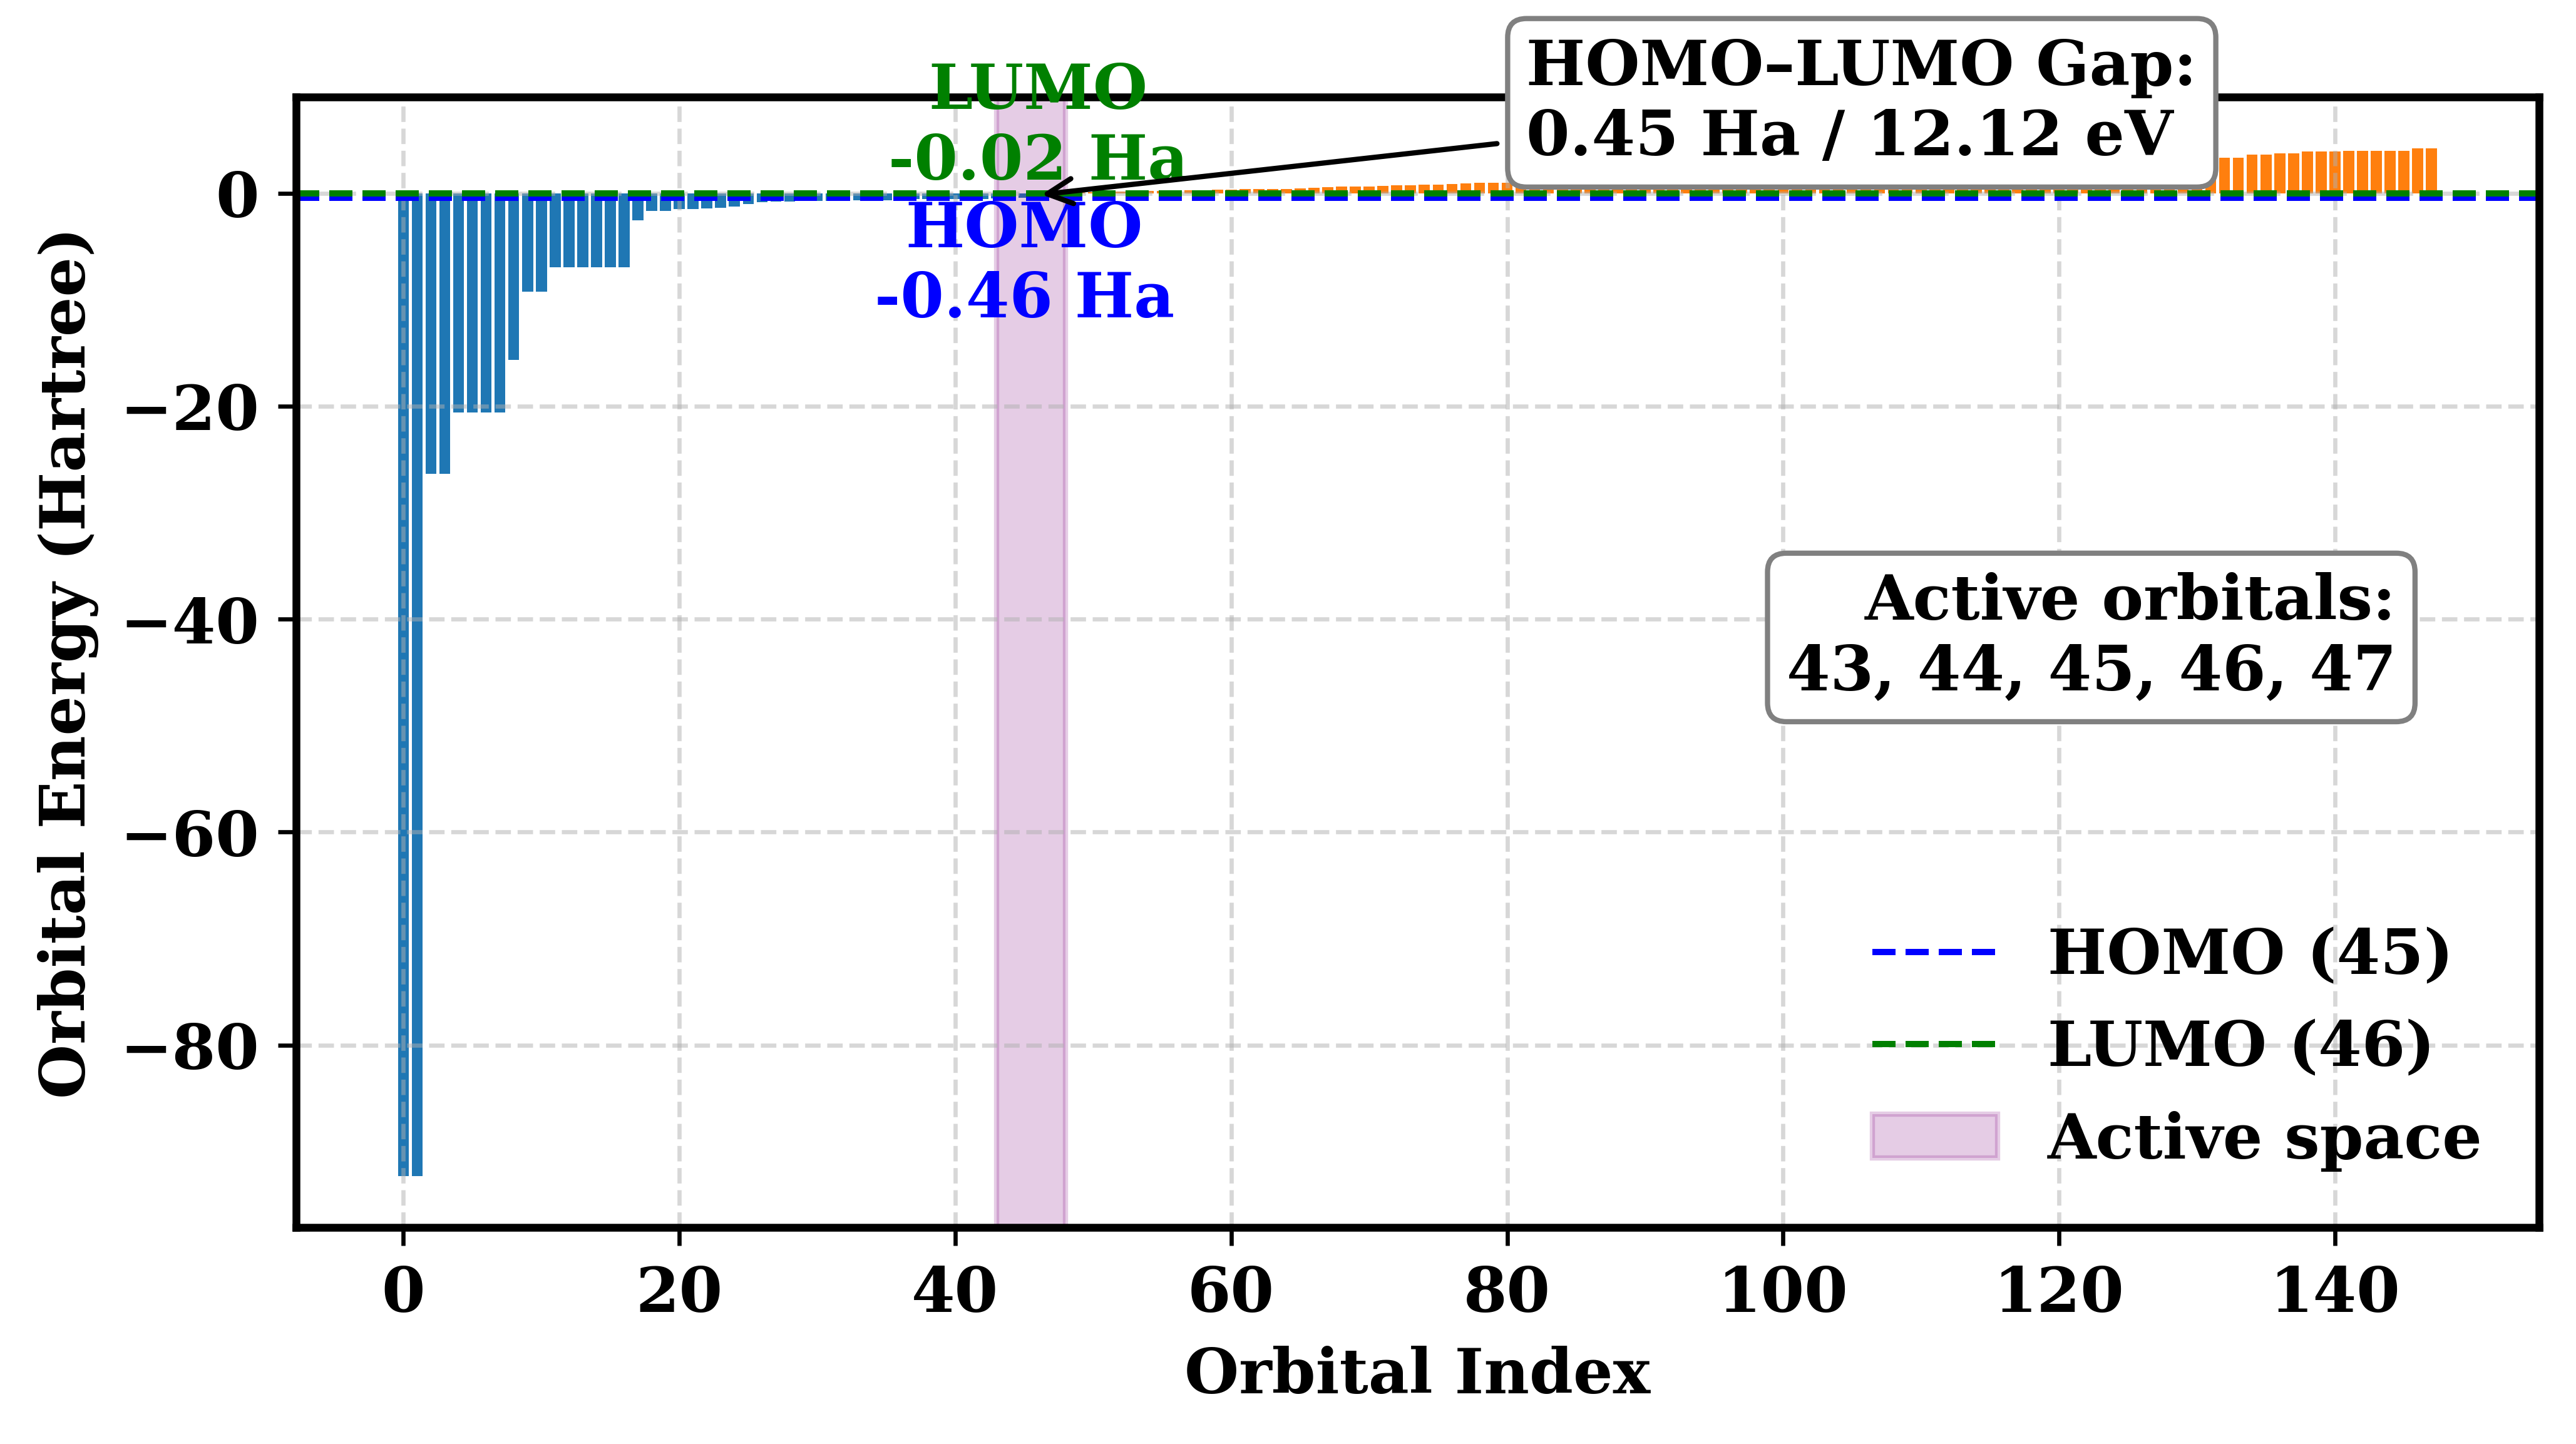

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import matplotlib as mpl

# ───────────────────────────────────────────────
# Global styling: Times New Roman, 600 DPI
# ───────────────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 600,
    'savefig.dpi': 600
})

# ───────────────────────────────────────────────
# Inputs from PySCF or dummy data for testing
# ───────────────────────────────────────────────
# Replace with:
mo_energies = mf.mo_energy
n_electrons = mol.nelectron

#mo_energies = np.sort(np.random.uniform(-1.5, 1.5, 80))  # Placeholder energies
#n_electrons = 78  # Closed-shell system with 39 occupied orbitals

# ───────────────────────────────────────────────
# HOMO & LUMO detection
# ───────────────────────────────────────────────
homo = n_electrons // 2 - 1
lumo = homo + 1
homo_energy = mo_energies[homo]
lumo_energy = mo_energies[lumo]
gap_ha = lumo_energy - homo_energy
gap_ev = gap_ha * 27.2114  # Ha → eV

# ───────────────────────────────────────────────
# Active space definition (HOMO ± window)
# ───────────────────────────────────────────────
window = 2
active_start = max(homo - window, 0)
active_end = min(lumo + window, len(mo_energies) - 1)
active_orbitals = list(range(active_start, active_end))

# ───────────────────────────────────────────────
# Plotting
# ───────────────────────────────────────────────
plt.figure(figsize=(7, 4))

# Color bars: occupied (blue), virtual (orange)
colors = ['tab:blue' if i <= homo else 'tab:orange' for i in range(len(mo_energies))]
plt.bar(range(len(mo_energies)), mo_energies, color=colors)

# Draw HOMO and LUMO lines
plt.axhline(homo_energy, color='blue', linestyle='--', linewidth=1.2, label=f'HOMO ({homo})')
plt.axhline(lumo_energy, color='green', linestyle='--', linewidth=1.2, label=f'LUMO ({lumo})')

# Shade active space
plt.axvspan(active_start, active_end, color='purple', alpha=0.2,
            label=f'Active space')# (HOMO±{window})')

# Annotate HOMO and LUMO
plt.text(homo, homo_energy - 0.1, f'HOMO\n{homo_energy:.2f} Ha',
         ha='center', va='top', fontsize=12, color='blue', fontweight='bold')
plt.text(lumo, lumo_energy + 0.1, f'LUMO\n{lumo_energy:.2f} Ha',
         ha='center', va='bottom', fontsize=12, color='green', fontweight='bold')

# Annotate HOMO–LUMO gap
plt.annotate(f"HOMO–LUMO Gap:\n{gap_ha:.2f} Ha / {gap_ev:.2f} eV",
             xy=((homo + lumo) / 2, (homo_energy + lumo_energy) / 2),
             xytext=(len(mo_energies) * 0.55, max(mo_energies) * 0.85),
             arrowprops=dict(arrowstyle="->", color='black'),
             bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray"),
             fontsize=12, fontweight='bold')

# Wrap active orbitals into multiple lines (8 per line)
lines = [", ".join(map(str, active_orbitals[i:i+8]))
         for i in range(0, len(active_orbitals), 8)]
wrapped_text = "\n".join(lines)

# Add active orbital indices inside the plot (top-right)
plt.gcf().text(0.92, 0.6,
               f"Active orbitals:\n{wrapped_text}",
               ha='right', va='top',
               fontsize=12,
               fontweight='bold',
               bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray"))

# Final plot settings
plt.xlabel('Orbital Index', fontsize=12, fontweight='bold')
plt.ylabel('Orbital Energy (Hartree)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(prop=FontProperties(weight='bold', size=12), frameon=False)
plt.tight_layout()

# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# === Axis Tick Styling ===
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# Save and show
plt.savefig("LiFSI_orbital_energy_active_space.jpg", format='jpg', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA
from qiskit.primitives import Estimator


# Step 1: Geometry for LiFSI
lifsi_geometry = (
    "N 0.0000 0.0000 0.4842; "
    "S 0.0000 1.4573 -0.2359; "
    "O 1.2588 1.8319 -0.8267; "
    "O -1.2588 1.8319 -0.8267; "
    "F 0.0000 2.1851 1.3085; "
    "S 0.0000 -1.4573 -0.2359; "
    "O 1.2588 -1.8319 -0.8267; "
    "O -1.2588 -1.8319 -0.8267; "
    "F 0.0000 -2.1851 1.3085; "
    "Li 0.0000 0.0000 2.3536"
)


# === Step 1: Define the LiFSI molecule ===
driver = PySCFDriver(
    atom= lifsi_geometry,
    basis="631g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)
es_problem = driver.run()

print("Spatial orbitals :", es_problem.num_spatial_orbitals)
print("Spin Orbitals", es_problem.num_spin_orbitals)
# How many physical electrons (α + β)?
n_alpha, n_beta = es_problem.num_particles
print("Electrons        :", n_alpha + n_beta, f"({n_alpha} α, {n_beta} β)")
no_of_qubit = 2*es_problem.num_spatial_orbitals
print("Number Qubit needed :", no_of_qubit)

# === Step 2: Freeze core + remove high-energy virtuals ===
freeze_transformer = FreezeCoreTransformer(
    freeze_core=list(range(0, 42)),   # Core
    remove_orbitals=list(range(49, es_problem.num_spatial_orbitals))            # Virtual
)
es_problem_reduced = freeze_transformer.transform(es_problem)

# === Step 3: Reduce active space (adjust electrons/orbitals as needed) ===
active_transformer = ActiveSpaceTransformer(
    num_electrons=6,
    num_spatial_orbitals=4          # 3 orbitals × 2 = 6 qubits
)
es_problem_active = active_transformer.transform(es_problem_reduced)

# === Step 4: Build qubit Hamiltonian ===
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(es_problem_active.second_q_ops()[0])
num_particles = es_problem_active.num_particles
num_spatial_orbitals = es_problem_active.num_spatial_orbitals

# === Step 5: Ansatz and initial state ===
init_state = HartreeFock(num_spatial_orbitals, num_particles, mapper)
ansatz = UCCSD(num_spatial_orbitals, num_particles, mapper, initial_state=init_state)
#ansatz = EfficientSU2(qubit_hamiltonian.num_qubits)

# === Step 6: VQE setup ===
#optimizer = SLSQP(maxiter=1000)
optimizer = COBYLA(maxiter=10000)
estimator = Estimator()

vqe_solver = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

solver = GroundStateEigensolver(mapper, vqe_solver)
result = solver.solve(es_problem_active)

# === Step 7: Output results ===
print("\n Molecule: LiFSI (active space)")
print(" Qubits used:", qubit_hamiltonian.num_qubits)
print("Particles:", num_particles)
print("Spatial Orbitals:", num_spatial_orbitals)
print("Ground state energy (Hartree):", result.total_energies[0].real)
print("Optimal parameters:", result.raw_result.optimal_point)

# Optional: visualize ansatz
#ansatz.assign_parameters(result.raw_result.optimal_point).decompose(reps=3).draw("mpl", style="iqp")

Spatial orbitals : 98
Spin Orbitals 196
Electrons        : 92 (46 α, 46 β)
Number Qubit needed : 196

 Molecule: LiFSI (active space)
 Qubits used: 8
Particles: (3, 3)
Spatial Orbitals: 4
Ground state energy (Hartree): -1354.378187182106
Optimal parameters: [ 3.37442804e-05  1.57953261e-05  3.16662865e-05 -4.98099776e-05
  6.88673433e-05 -6.15976308e-05 -2.99850076e-04 -3.17012117e-06
 -3.21803017e-05  1.76543700e-05 -3.30657395e-04 -3.68385103e-05
  2.17275326e-05  1.42473264e-05 -3.42112483e-04]


In [1]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA
from qiskit.primitives import Estimator


# Step 1: Geometry for LiFSI
lifsi_geometry = (
    "N 0.0000 0.0000 0.4842; "
    "S 0.0000 1.4573 -0.2359; "
    "O 1.2588 1.8319 -0.8267; "
    "O -1.2588 1.8319 -0.8267; "
    "F 0.0000 2.1851 1.3085; "
    "S 0.0000 -1.4573 -0.2359; "
    "O 1.2588 -1.8319 -0.8267; "
    "O -1.2588 -1.8319 -0.8267; "
    "F 0.0000 -2.1851 1.3085; "
    "Li 0.0000 0.0000 2.3536"
)


driver = PySCFDriver(atom=lifsi_geometry,
                     basis='cc-pVDZ', #"631g*",
                     charge=0,
                     spin=0,
                     unit=DistanceUnit.ANGSTROM)
problem = driver.run()

print("── Original HF problem ─────────────────────────")
print("Spatial orbitals :", problem.num_spatial_orbitals)
print("Spin  orbitals   :", problem.num_spin_orbitals)
na, nb = problem.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 2.  Freeze‑core + trim high‑energy virtuals
# ──────────────────────────────────────────────────────────────────────────────
freeze_core     = list(range(0, 41))                            # lowest 22 MOs
remove_orbitals = list(range(49, problem.num_spatial_orbitals)) # 29 … 75

fc = FreezeCoreTransformer(freeze_core=False,
                           remove_orbitals=remove_orbitals+freeze_core)
problem_red = fc.transform(problem)

# Show what survived this step
all_orbs     = set(range(problem.num_spatial_orbitals))
frozen_orbs  = set(freeze_core)
removed_orbs = set(remove_orbitals)
kept_fc      = sorted(all_orbs - frozen_orbs - removed_orbs)

print("── After FreezeCoreTransformer ────────────────")
print("Frozen orbitals   :", sorted(freeze_core))
print("Removed virtuals  :", sorted(remove_orbitals))
print("Kept orbitals     :", kept_fc)
print("Spatial orbitals  :", problem_red.num_spatial_orbitals, "\n")
na, nb = problem_red.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 3.  Active‑space reduction (6 e⁻ in 4 MOs)
# ──────────────────────────────────────────────────────────────────────────────
# Choose which of the kept orbitals will be active.
# Example below: take the first four kept orbitals (indices 0,1,2,3 in problem_red).
active_orbs_reduced = [2, 3, 4, 5, 6]          # change if you prefer a different window
ast = ActiveSpaceTransformer(
    num_electrons=6,
    num_spatial_orbitals=5,
    active_orbitals=active_orbs_reduced
)
problem_act = ast.transform(problem_red)

# Map those active indices back to original PySCF numbering
active_original = [kept_fc[i] for i in active_orbs_reduced]

print("── Active space ───────────────────────────────")
print("Active orbitals (re‑indexed) :", active_orbs_reduced)
print("Active orbitals (original HF):", active_original)
print("Spatial orbitals              :", problem_act.num_spatial_orbitals)
na, nb = problem_act.num_particles
print(f"Electrons                     : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 4.  Qubit mapping, ansatz, VQE
# ──────────────────────────────────────────────────────────────────────────────
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(problem_act.second_q_ops()[0])

init_state = HartreeFock(problem_act.num_spatial_orbitals,
                         problem_act.num_particles, mapper)
ansatz = UCCSD(problem_act.num_spatial_orbitals,
               problem_act.num_particles, mapper,
               initial_state=init_state)

vqe = VQE(estimator=Estimator(),
          ansatz=ansatz,
          optimizer=COBYLA(maxiter=10000))
vqe.initial_point = [0.0] * ansatz.num_parameters

gs_solver = GroundStateEigensolver(mapper, vqe)
result = gs_solver.solve(problem_act)

print("── VQE result ────────────────────────────────")
print("Qubits used          :", qubit_hamiltonian.num_qubits)
print("Ground‑state energy  :", result.total_energies[0].real, "Ha")
print("Optimal parameters   :", result.raw_result.optimal_point)

── Original HF problem ─────────────────────────
Spatial orbitals : 148
Spin  orbitals   : 296
Electrons        : 92 (46 α, 46 β)

── After FreezeCoreTransformer ────────────────
Frozen orbitals   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
Removed virtuals  : [49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147]
Kept orbitals     : [41, 42, 43, 44, 45, 46, 47, 48]
Spatial orbitals  : 8 

Electrons        : 10 (5 α, 5 β)

── Active space ───────────────────────────────
Active orbitals (re‑in

In [3]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_nature.second_q.algorithms import QEOM, EvaluationRule
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# === Step 1: Molecule Geometry ===
lifsi_geometry = (
    "N 0.0000 0.0000 0.4842; "
    "S 0.0000 1.4573 -0.2359; "
    "O 1.2588 1.8319 -0.8267; "
    "O -1.2588 1.8319 -0.8267; "
    "F 0.0000 2.1851 1.3085; "
    "S 0.0000 -1.4573 -0.2359; "
    "O 1.2588 -1.8319 -0.8267; "
    "O -1.2588 -1.8319 -0.8267; "
    "F 0.0000 -2.1851 1.3085; "
    "Li 0.0000 0.0000 2.3536"
)

driver = PySCFDriver(
    atom=lifsi_geometry,
    basis="631g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)
es_problem = driver.run()

# === Step 2: Freeze core + reduce orbitals ===
freeze_transformer = FreezeCoreTransformer(
    freeze_core=list(range(0, 43)),
    remove_orbitals=list(range(48, es_problem.num_spatial_orbitals))
)
es_problem_reduced = freeze_transformer.transform(es_problem)

# === Step 3: Active space ===
active_transformer = ActiveSpaceTransformer(num_electrons=6, num_spatial_orbitals=4)
es_problem_active = active_transformer.transform(es_problem_reduced)

# === Step 4: Qubit mapping ===
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(es_problem_active.second_q_ops()[0])
num_particles = es_problem_active.num_particles
num_spatial_orbitals = es_problem_active.num_spatial_orbitals

# === Step 5: Ansatz ===
init_state = HartreeFock(num_spatial_orbitals, num_particles, mapper)
ansatz = UCCSD(num_spatial_orbitals, num_particles, mapper, initial_state=init_state)

# === Step 6: VQE Ground State Solver ===
optimizer = COBYLA(maxiter=10000)
estimator = Estimator()
vqe_solver = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

g_solver = GroundStateEigensolver(mapper, vqe_solver)

# === Step 7: Excited State Solver using qEOM ===
qeom_solver = QEOM(g_solver, estimator, "sd", EvaluationRule.DIAG)  # Use both single and double excitations
result = qeom_solver.solve(es_problem_active)

# === Step 8: Print Results ===
print("\n=== LiFSI Excited State Energies ===")
energies = [res.real for res in result.total_energies]
ground_state_energy = energies[0]

for i, energy in enumerate(energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_E = energy - ground_state_energy if i > 0 else 0
    print(f"{label} State Energy: {energy:.6f} Hartree", end="")
    if i > 0:
        print(f"   ΔE = {delta_E:.6f} Hartree ≈ {delta_E*27.2114:.2f} eV")
    else:
        print()


=== LiFSI Excited State Energies ===
Ground State Energy: -1354.378187 Hartree
Excited 1 State Energy: -1354.010028 Hartree   ΔE = 0.368160 Hartree ≈ 10.02 eV
Excited 2 State Energy: -1354.009274 Hartree   ΔE = 0.368914 Hartree ≈ 10.04 eV
Excited 3 State Energy: -1353.988099 Hartree   ΔE = 0.390088 Hartree ≈ 10.61 eV
Excited 4 State Energy: -1353.987273 Hartree   ΔE = 0.390914 Hartree ≈ 10.64 eV
Excited 5 State Energy: -1353.957230 Hartree   ΔE = 0.420957 Hartree ≈ 11.45 eV
Excited 6 State Energy: -1353.956549 Hartree   ΔE = 0.421639 Hartree ≈ 11.47 eV
Excited 7 State Energy: -1353.358933 Hartree   ΔE = 1.019254 Hartree ≈ 27.74 eV
Excited 8 State Energy: -1353.355633 Hartree   ΔE = 1.022554 Hartree ≈ 27.83 eV
Excited 9 State Energy: -1353.340893 Hartree   ΔE = 1.037294 Hartree ≈ 28.23 eV
Excited 10 State Energy: -1353.339308 Hartree   ΔE = 1.038879 Hartree ≈ 28.27 eV
Excited 11 State Energy: -1353.333133 Hartree   ΔE = 1.045054 Hartree ≈ 28.44 eV
Excited 12 State Energy: -1353.323890 

In [7]:
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM, ExcitedStatesEigensolver
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.units import DistanceUnit
from qiskit_algorithms import NumPyEigensolver, VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit.primitives import Estimator
from qiskit_nature.second_q.algorithms import EvaluationRule

# === Step 1: Geometry and driver ===
lifsi_geometry = (
    "N 0.0000 0.0000 0.4842; "
    "S 0.0000 1.4573 -0.2359; "
    "O 1.2588 1.8319 -0.8267; "
    "O -1.2588 1.8319 -0.8267; "
    "F 0.0000 2.1851 1.3085; "
    "S 0.0000 -1.4573 -0.2359; "
    "O 1.2588 -1.8319 -0.8267; "
    "O -1.2588 -1.8319 -0.8267; "
    "F 0.0000 -2.1851 1.3085; "
    "Li 0.0000 0.0000 2.3536"
)

driver = PySCFDriver(atom=lifsi_geometry, basis="631g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
es_problem = driver.run()

# === Step 2: Transform for active space ===
es_problem_reduced = FreezeCoreTransformer(
    freeze_core=list(range(0, 43)),
    remove_orbitals=list(range(48, es_problem.num_spatial_orbitals))
).transform(es_problem)

es_problem_active = ActiveSpaceTransformer(
    num_electrons=6,
    num_spatial_orbitals=4
).transform(es_problem_reduced)

mapper = JordanWignerMapper()

# === Step 3: Classical exact eigensolver ===
numpy_solver = NumPyEigensolver(k=8)
numpy_excited_solver = ExcitedStatesEigensolver(mapper, numpy_solver)
numpy_results = numpy_excited_solver.solve(es_problem_active)

# === Step 4: VQE + QEOM ===
estimator = Estimator()
ansatz = UCCSD(
    es_problem_active.num_spatial_orbitals,
    es_problem_active.num_particles,
    mapper,
    initial_state=HartreeFock(
        es_problem_active.num_spatial_orbitals,
        es_problem_active.num_particles,
        mapper,
    ),
)
vqe_solver = VQE(estimator, ansatz, SLSQP())
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

gse = GroundStateEigensolver(mapper, vqe_solver)
qeom_solver = QEOM(gse, estimator, "sd", EvaluationRule.ALL)
qeom_results = qeom_solver.solve(es_problem_active)

# === Step 5: Compare Results ===
print("\n=== NumPy (Exact) Excited State Energies of LiFSI===")
for i, e in enumerate(numpy_results.total_energies):
    print(f"State {i}: {e.real:.6f} Hartree")

print("\n=== VQE + qEOM Excited State Energies of LiFSI===")
gs_energy = qeom_results.total_energies[0].real
for i, e in enumerate(qeom_results.total_energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_e = e.real - gs_energy if i > 0 else 0
    print(f"{label} State: {e.real:.6f} Hartree", end="")
    if i > 0:
        print(f"   ΔE = {delta_e:.6f} Hartree ≈ {delta_e * 27.2114:.2f} eV")
    else:
        print()

bandgap = qeom_results.computed_energies[1] - qeom_results.computed_energies[0]
print("\n=== HOMO and LUMO gap of LiFSI ===")
print(f" ΔE_gap = {bandgap:.6f} Hartree ≈ {bandgap * 27.2114:.2f} eV")
#bandgap # in Hartree



=== NumPy (Exact) Excited State Energies of LiFSI===
State 0: -1354.391061 Hartree
State 1: -1354.391061 Hartree
State 2: -1354.378187 Hartree
State 3: -1354.167288 Hartree
State 4: -1354.010028 Hartree
State 5: -1354.010028 Hartree
State 6: -1354.010028 Hartree
State 7: -1354.009274 Hartree

=== VQE + qEOM Excited State Energies of LiFSI===
Ground State: -1354.378187 Hartree
Excited 1 State: -1354.010028 Hartree   ΔE = 0.368160 Hartree ≈ 10.02 eV
Excited 2 State: -1354.009274 Hartree   ΔE = 0.368914 Hartree ≈ 10.04 eV
Excited 3 State: -1353.988099 Hartree   ΔE = 0.390088 Hartree ≈ 10.61 eV
Excited 4 State: -1353.987273 Hartree   ΔE = 0.390914 Hartree ≈ 10.64 eV
Excited 5 State: -1353.957230 Hartree   ΔE = 0.420957 Hartree ≈ 11.45 eV
Excited 6 State: -1353.956549 Hartree   ΔE = 0.421639 Hartree ≈ 11.47 eV
Excited 7 State: -1353.358933 Hartree   ΔE = 1.019254 Hartree ≈ 27.74 eV
Excited 8 State: -1353.355633 Hartree   ΔE = 1.022554 Hartree ≈ 27.83 eV
Excited 9 State: -1353.340893 Hartre

Running VQE at Li–F distance 1.50 Å ...
Running VQE at Li–F distance 1.76 Å ...
Running VQE at Li–F distance 2.03 Å ...
Running VQE at Li–F distance 2.29 Å ...
Running VQE at Li–F distance 2.56 Å ...
Running VQE at Li–F distance 2.82 Å ...
Running VQE at Li–F distance 3.09 Å ...
Running VQE at Li–F distance 3.35 Å ...
Running VQE at Li–F distance 3.62 Å ...
Running VQE at Li–F distance 3.88 Å ...
Running VQE at Li–F distance 4.15 Å ...
Running VQE at Li–F distance 4.41 Å ...
Running VQE at Li–F distance 4.68 Å ...
Running VQE at Li–F distance 4.94 Å ...
Running VQE at Li–F distance 5.21 Å ...
Running VQE at Li–F distance 5.47 Å ...
Running VQE at Li–F distance 5.74 Å ...
Running VQE at Li–F distance 6.00 Å ...

✅ Saved minimum-energy geometry to LiFSI_min.xyz


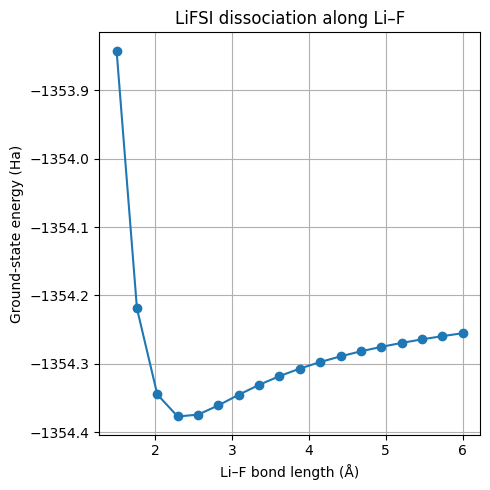

In [11]:
###############################################################
# Na–F dissociation curve with VQE (active‑space UCCSD)
###############################################################
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# ---------------- USER SETTINGS -----------------
basis                 = "6-31g"
freeze_core_list      = list(range(0, 43))
virtual_trim_start    = 48
active_nelec          = 6
active_norb           = 4
optimizer_maxiter     = 10000
distances             = np.linspace(1.5, 6.0, 18)   # 18 points → 1.5 … 6.0 Å
# ------------------------------------------------


def make_geometry(d):
    """Return LiFSI geometry string with Na along –z at distance d from P."""
    return (
        f"N  0.000000  0.000000   0.484246; "
        f"S  0.000000  1.457308  -0.235914; "
        f"O  1.258754  1.831940  -0.826699; "
        f"O -1.258754  1.831940  -0.826699; "
        f"F  0.000000  2.185090   1.308501; "
        f"S  0.000000 -1.457308  -0.235914; "
        f"O  1.258754 -1.831940  -0.826699; "
        f"O -1.258754 -1.831940  -0.826699; "
        f"F  0.000000 -2.185090   1.308501; "
        f"Li 0.000000  0.000000   {d:8.6f}"
    )


def vqe_energy(geom):
    """Return VQE ground‑state energy for a given geometry."""
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    prob = driver.run()

    # Freeze core and trim virtuals
    freeze = FreezeCoreTransformer(
        freeze_core=freeze_core_list,
        remove_orbitals=list(range(virtual_trim_start, prob.num_spatial_orbitals)),
    )
    prob = freeze.transform(prob)

    # Active space
    active = ActiveSpaceTransformer(
        num_electrons=active_nelec, num_spatial_orbitals=active_norb
    )
    prob = active.transform(prob)

    mapper = JordanWignerMapper()
    qubit_op = mapper.map(prob.second_q_ops()[0])

    init = HartreeFock(active_norb, prob.num_particles, mapper)
    ans = UCCSD(active_norb, prob.num_particles, mapper, initial_state=init)

    vqe = VQE(
        Estimator(),
        ansatz=ans,
        optimizer=COBYLA(maxiter=optimizer_maxiter),
        initial_point=[0.0] * ans.num_parameters,
    )
    solver = GroundStateEigensolver(mapper, vqe)
    res = solver.solve(prob)
    return res.total_energies[0].real


# ---------- sweep distances ----------
energies = []
geometries = []  # keep geom strings for later
for d in distances:
    print(f"Running VQE at Li–F distance {d:4.2f} Å ...")
    geom_str = make_geometry(d)
    geometries.append(geom_str)
    energies.append(vqe_energy(geom_str))

energies = np.array(energies)

# ---------- find minimum and save XYZ ----------
idx_min = np.argmin(energies)
best_d = distances[idx_min]
best_geom = geometries[idx_min]

# Convert geom string → XYZ lines
atoms = [tok.strip() for tok in best_geom.split(";") if tok.strip()]
xyz_lines = [f"{len(atoms)}", f"LiFSI minimum @ Li–F = {best_d:.2f} Å"]
for line in atoms:
    # split "El x y z" → keep as-is (PySCF-compatible order)
    xyz_lines.append(line.replace("  ", " ").replace(" ;", ""))

xyz_path = Path("LiFSI_min.xyz")
xyz_path.write_text("\n".join(xyz_lines))
print(f"\n✅ Saved minimum-energy geometry to {xyz_path}")

# ---------- plot ----------
plt.figure(figsize=(5, 5))
plt.plot(distances, energies, "-o")
plt.xlabel("Li–F bond length (Å)")
plt.ylabel("Ground‑state energy (Ha)")
plt.title("LiFSI dissociation along Li–F")
plt.grid(True)
plt.tight_layout()
plt.savefig("LiFSI_Li-F_dissociation_curve.png", dpi=300)
plt.show()

Distance: 1.50 Å, Energy: -1354.638377 Ha
Distance: 1.76 Å, Energy: -1354.998543 Ha
Distance: 1.76 Å, Energy: -1354.998543 Ha
Distance: 2.03 Å, Energy: -1355.115845 Ha
Distance: 2.03 Å, Energy: -1355.115845 Ha
Distance: 2.29 Å, Energy: -1355.145257 Ha
Distance: 2.29 Å, Energy: -1355.145257 Ha
Distance: 2.56 Å, Energy: -1355.142755 Ha
Distance: 2.56 Å, Energy: -1355.142755 Ha
Distance: 2.82 Å, Energy: -1355.129881 Ha
Distance: 2.82 Å, Energy: -1355.129881 Ha
Distance: 3.09 Å, Energy: -1355.114857 Ha
Distance: 3.09 Å, Energy: -1355.114857 Ha
Distance: 3.35 Å, Energy: -1355.100475 Ha
Distance: 3.35 Å, Energy: -1355.100475 Ha
Distance: 3.62 Å, Energy: -1355.087502 Ha
Distance: 3.62 Å, Energy: -1355.087502 Ha
Distance: 3.88 Å, Energy: -1355.076034 Ha
Distance: 3.88 Å, Energy: -1355.076034 Ha
Distance: 4.15 Å, Energy: -1355.065967 Ha
Distance: 4.15 Å, Energy: -1355.065967 Ha
Distance: 4.41 Å, Energy: -1355.057139 Ha
Distance: 4.41 Å, Energy: -1355.057139 Ha
Distance: 4.68 Å, Energy: -1355.04

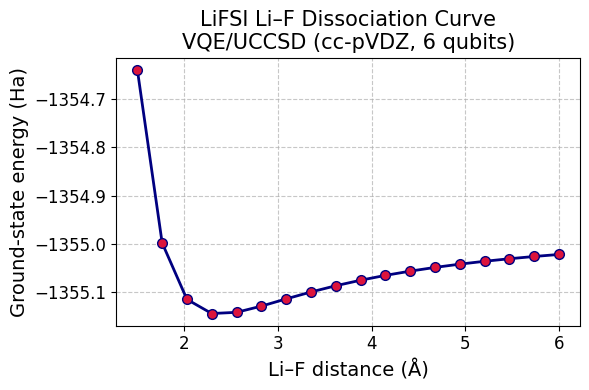

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# Li–F dissociation distances: include 2.3536 Å exactly
lf_distances = np.array(sorted(set(np.append(np.linspace(1.5, 6.0, 18), [2.3536]))))
vqe_energies = []
qubit_count = None
basis_set = 'cc-pVDZ'

for d in lf_distances:
    lifsi_geometry = (
        f"N 0.0000 0.0000 0.4842; "
        f"S 0.0000 1.4573 -0.2359; "
        f"O 1.2588 1.8319 -0.8267; "
        f"O -1.2588 1.8319 -0.8267; "
        f"F 0.0000 2.1851 1.3085; "
        f"S 0.0000 -1.4573 -0.2359; "
        f"O 1.2588 -1.8319 -0.8267; "
        f"O -1.2588 -1.8319 -0.8267; "
        f"F 0.0000 -2.1851 1.3085; "
        f"Li 0.0000 0.0000 {d:8.6f}"
    )
    driver = PySCFDriver(atom=lifsi_geometry,
                         basis=basis_set,
                         charge=0,
                         spin=0,
                         unit=DistanceUnit.ANGSTROM)
    problem = driver.run()
    freeze_core     = list(range(0, 41))
    remove_orbitals = list(range(49, problem.num_spatial_orbitals))
    fc = FreezeCoreTransformer(freeze_core=False,
                               remove_orbitals=remove_orbitals+freeze_core)
    problem_red = fc.transform(problem)
    all_orbs     = set(range(problem.num_spatial_orbitals))
    frozen_orbs  = set(freeze_core)
    removed_orbs = set(remove_orbitals)
    kept_fc      = sorted(all_orbs - frozen_orbs - removed_orbs)
    active_orbs_reduced = [3, 4, 5]
    ast = ActiveSpaceTransformer(
        num_electrons=4,
        num_spatial_orbitals=3,
        active_orbitals=active_orbs_reduced
    )
    problem_act = ast.transform(problem_red)
    mapper = JordanWignerMapper()
    qubit_hamiltonian = mapper.map(problem_act.second_q_ops()[0])
    if qubit_count is None:
        qubit_count = qubit_hamiltonian.num_qubits
    init_state = HartreeFock(problem_act.num_spatial_orbitals,
                             problem_act.num_particles, mapper)
    ansatz = UCCSD(problem_act.num_spatial_orbitals,
                   problem_act.num_particles, mapper,
                   initial_state=init_state)
    vqe = VQE(estimator=Estimator(),
              ansatz=ansatz,
              optimizer=COBYLA(maxiter=10000))
    vqe.initial_point = [0.0] * ansatz.num_parameters
    gs_solver = GroundStateEigensolver(mapper, vqe)
    result = gs_solver.solve(problem_act)
    energy = result.total_energies[0].real
    vqe_energies.append(energy)
    print(f"Distance: {d:.4f} Å, Energy: {energy:.6f} Ha")

# Publication-quality plot
plt.figure(figsize=(6, 4))
plt.plot(lf_distances, vqe_energies, '-o', color='navy', markerfacecolor='crimson', markersize=7, linewidth=2)
plt.xlabel('Li–F distance (Å)', fontsize=14)
plt.ylabel('Ground-state energy (Ha)', fontsize=14)
plt.title('LiFSI Li–F Dissociation Curve', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
# Add basis set and qubit count as annotation inside the plot
plt.annotate(f'VQE/UCCSD ({basis_set}, {qubit_count} qubits)', xy=(0.98, 0.02), xycoords='axes fraction', fontsize=12, color='dimgray', ha='right', va='bottom', bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.7))
plt.tight_layout()
plt.savefig('LiFSI_Li-F_dissociation_curve.png', dpi=400, bbox_inches='tight')
plt.show()

Distance: 1.5000 Å, Energy: -1354.638377 Ha
Distance: 1.7647 Å, Energy: -1354.998543 Ha
Distance: 2.0294 Å, Energy: -1355.115845 Ha
Distance: 2.2941 Å, Energy: -1355.145257 Ha
Distance: 2.3536 Å, Energy: -1355.146390 Ha
Distance: 2.5588 Å, Energy: -1355.142755 Ha
Distance: 2.8235 Å, Energy: -1355.129881 Ha
Distance: 3.0882 Å, Energy: -1355.114857 Ha
Distance: 3.3529 Å, Energy: -1355.100475 Ha
Distance: 3.6176 Å, Energy: -1355.087502 Ha
Distance: 3.8824 Å, Energy: -1355.076034 Ha
Distance: 4.1471 Å, Energy: -1355.065967 Ha
Distance: 4.4118 Å, Energy: -1355.057139 Ha
Distance: 4.6765 Å, Energy: -1355.049397 Ha
Distance: 4.9412 Å, Energy: -1355.042605 Ha
Distance: 5.2059 Å, Energy: -1355.036639 Ha
Distance: 5.4706 Å, Energy: -1355.031367 Ha
Distance: 5.7353 Å, Energy: -1355.026666 Ha
Distance: 6.0000 Å, Energy: -1355.022426 Ha


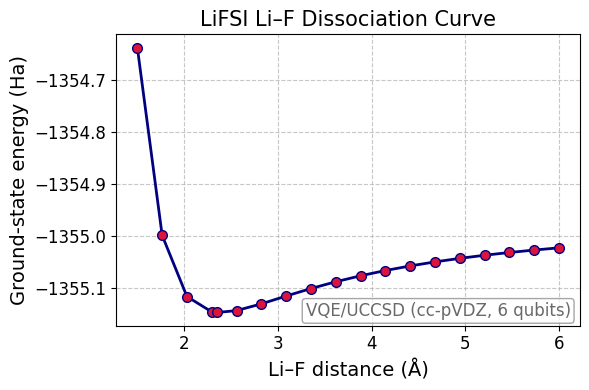

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# Li–F dissociation distances: include 2.3536 Å exactly
lf_distances = np.array(sorted(set(np.append(np.linspace(1.5, 6.0, 18), [2.3536]))))
vqe_energies = []
qubit_count = None
basis_set = 'cc-pVDZ'

for d in lf_distances:
    lifsi_geometry = (
        f"N 0.0000 0.0000 0.4842; "
        f"S 0.0000 1.4573 -0.2359; "
        f"O 1.2588 1.8319 -0.8267; "
        f"O -1.2588 1.8319 -0.8267; "
        f"F 0.0000 2.1851 1.3085; "
        f"S 0.0000 -1.4573 -0.2359; "
        f"O 1.2588 -1.8319 -0.8267; "
        f"O -1.2588 -1.8319 -0.8267; "
        f"F 0.0000 -2.1851 1.3085; "
        f"Li 0.0000 0.0000 {d:8.6f}"
    )
    driver = PySCFDriver(atom=lifsi_geometry,
                         basis=basis_set,
                         charge=0,
                         spin=0,
                         unit=DistanceUnit.ANGSTROM)
    problem = driver.run()
    freeze_core     = list(range(0, 41))
    remove_orbitals = list(range(49, problem.num_spatial_orbitals))
    fc = FreezeCoreTransformer(freeze_core=False,
                               remove_orbitals=remove_orbitals+freeze_core)
    problem_red = fc.transform(problem)
    all_orbs     = set(range(problem.num_spatial_orbitals))
    frozen_orbs  = set(freeze_core)
    removed_orbs = set(remove_orbitals)
    kept_fc      = sorted(all_orbs - frozen_orbs - removed_orbs)
    active_orbs_reduced = [3, 4, 5]
    ast = ActiveSpaceTransformer(
        num_electrons=4,
        num_spatial_orbitals=3,
        active_orbitals=active_orbs_reduced
    )
    problem_act = ast.transform(problem_red)
    mapper = JordanWignerMapper()
    qubit_hamiltonian = mapper.map(problem_act.second_q_ops()[0])
    if qubit_count is None:
        qubit_count = qubit_hamiltonian.num_qubits
    init_state = HartreeFock(problem_act.num_spatial_orbitals,
                             problem_act.num_particles, mapper)
    ansatz = UCCSD(problem_act.num_spatial_orbitals,
                   problem_act.num_particles, mapper,
                   initial_state=init_state)
    vqe = VQE(estimator=Estimator(),
              ansatz=ansatz,
              optimizer=COBYLA(maxiter=10000))
    vqe.initial_point = [0.0] * ansatz.num_parameters
    gs_solver = GroundStateEigensolver(mapper, vqe)
    result = gs_solver.solve(problem_act)
    energy = result.total_energies[0].real
    vqe_energies.append(energy)
    print(f"Distance: {d:.4f} Å, Energy: {energy:.6f} Ha")

# Save bond distances and energies to a .dat file
with open("LiFSI_dissociation_energies.dat", "w") as f:
    f.write("# Li–F bond distance (Å)    Ground-state energy (Ha)\n")
    for d, e in zip(lf_distances, vqe_energies):
        f.write(f"{d:8.4f}\t{e: .8f}\n")

# Publication-quality plot
plt.figure(figsize=(6, 4))
plt.plot(lf_distances, vqe_energies, '-o', color='navy', markerfacecolor='crimson', markersize=7, linewidth=2)
plt.xlabel('Li–F distance (Å)', fontsize=14)
plt.ylabel('Ground-state energy (Ha)', fontsize=14)
plt.title('LiFSI Li–F Dissociation Curve', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
# Add basis set and qubit count as annotation inside the plot
plt.annotate(f'VQE/UCCSD ({basis_set}, {qubit_count} qubits)', xy=(0.98, 0.02), xycoords='axes fraction', fontsize=12, color='dimgray', ha='right', va='bottom', bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.7))
plt.tight_layout()
plt.savefig('LiFSI_Li-F_dissociation_curve.png', dpi=400, bbox_inches='tight')
plt.show()


Running VQE dissociation curve for basis: sto3g
  Li–F = 1.50 Å : E = -1337.642511 Ha
  Li–F = 1.76 Å : E = -1338.018224 Ha
  Li–F = 2.03 Å : E = -1338.112603 Ha
  Li–F = 2.29 Å : E = -1338.114856 Ha
  Li–F = 2.35 Å : E = -1338.110155 Ha
  Li–F = 2.56 Å : E = -1338.087246 Ha
  Li–F = 2.82 Å : E = -1338.050720 Ha
  Li–F = 3.09 Å : E = -1338.012846 Ha
  Li–F = 3.35 Å : E = -1337.976822 Ha
  Li–F = 3.62 Å : E = -1337.944398 Ha
  Li–F = 3.88 Å : E = -1337.916550 Ha
  Li–F = 4.15 Å : E = -1337.893615 Ha
  Li–F = 4.41 Å : E = -1337.875341 Ha
  Li–F = 4.68 Å : E = -1337.861167 Ha
  Li–F = 4.94 Å : E = -1337.850535 Ha
  Li–F = 5.21 Å : E = -1337.843292 Ha
  Li–F = 5.47 Å : E = -1337.839885 Ha
  Li–F = 5.74 Å : E = -1337.839525 Ha
  Li–F = 6.00 Å : E = -1337.840494 Ha

Running VQE dissociation curve for basis: 631g*
  Li–F = 1.50 Å : E = -1354.598420 Ha
  Li–F = 1.76 Å : E = -1354.962545 Ha
  Li–F = 2.03 Å : E = -1355.079332 Ha
  Li–F = 2.29 Å : E = -1355.107889 Ha
  Li–F = 2.35 Å : E = -1355.

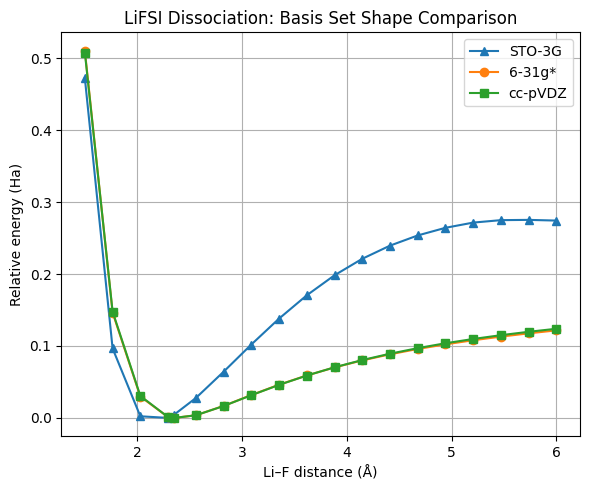

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# --- Settings ---
distances_sto3g = np.array(sorted(set(np.append(np.linspace(1.5, 6.0, 18), [2.3536]))))
distances_631g = np.array(sorted(set(np.append(np.linspace(1.5, 6.0, 18), [2.3536]))))
distances_ccpvdz = np.array(sorted(set(np.append(np.linspace(1.5, 6.0, 18), [2.3536]))))  # reduced grid for cc-pVDZ
basis_sets = {'sto3g': distances_sto3g, '631g*': distances_631g, 'cc-pVDZ': distances_ccpvdz}
energies_basis = {}

def vqe_energy_basis(geom: str, basis: str, n_active_elec=2, n_active_orb=2, active_indices=[4,5], maxiter=6000):
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    problem = driver.run()
    remove_orbs = list(range(49, problem.num_spatial_orbitals))
    fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=list(range(0,41)) + remove_orbs)
    problem_red = fc.transform(problem)
    ast = ActiveSpaceTransformer(num_electrons=n_active_elec, num_spatial_orbitals=n_active_orb, active_orbitals=active_indices)
    problem_act = ast.transform(problem_red)
    mapper = JordanWignerMapper()
    init_state = HartreeFock(n_active_orb, problem_act.num_particles, mapper)
    ansatz = UCCSD(n_active_orb, problem_act.num_particles, mapper, initial_state=init_state)
    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=maxiter), initial_point=[0.0] * ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    res = solver.solve(problem_act)
    return res.total_energies[0].real

for basis, dists in basis_sets.items():
    print(f"\nRunning VQE dissociation curve for basis: {basis}")
    energies = []
    for d in dists:
        geom = (
            f"N 0.0000 0.0000 0.4842; "
            f"S 0.0000 1.4573 -0.2359; "
            f"O 1.2588 1.8319 -0.8267; "
            f"O -1.2588 1.8319 -0.8267; "
            f"F 0.0000 2.1851 1.3085; "
            f"S 0.0000 -1.4573 -0.2359; "
            f"O 1.2588 -1.8319 -0.8267; "
            f"O -1.2588 -1.8319 -0.8267; "
            f"F 0.0000 -2.1851 1.3085; "
            f"Li 0.0000 0.0000 {d:6.4f}"
        )
        e = vqe_energy_basis(geom, basis)
        energies.append(e)
        print(f"  Li–F = {d:.2f} Å : E = {e:.6f} Ha")
    energies_basis[basis] = np.array(energies)

# Normalize each curve to its minimum value for better shape comparison
energies_shifted = {}
for basis, energies in energies_basis.items():
    energies_shifted[basis] = energies - np.min(energies)

# --- Plot normalized comparison ---
plt.figure(figsize=(6, 5))
plt.plot(distances_sto3g, energies_shifted['sto3g'], '^-', label='STO-3G')
plt.plot(distances_631g, energies_shifted['631g*'], 'o-', label='6-31g*')
plt.plot(distances_ccpvdz, energies_shifted['cc-pVDZ'], 's-', label='cc-pVDZ')

plt.xlabel('Li–F distance (Å)')
plt.ylabel('Relative energy (Ha)')
plt.title('LiFSI Dissociation: Basis Set Shape Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("LiFSI_dissociation_basis_shape_aligned.png", dpi=300)
plt.show()

Li–F = 1.50 Å | HF = -1354.638375 | FCI = -1354.638379 | VQE = -1354.638379
Li–F = 1.76 Å | HF = -1354.998538 | FCI = -1354.998541 | VQE = -1354.998541
Li–F = 2.03 Å | HF = -1355.115843 | FCI = -1355.119604 | VQE = -1355.115845
Li–F = 2.29 Å | HF = -1355.145257 | FCI = -1355.158517 | VQE = -1355.145259
Li–F = 2.56 Å | HF = -1355.142756 | FCI = -1355.166394 | VQE = -1355.142758
Li–F = 2.82 Å | HF = -1355.129883 | FCI = -1355.163997 | VQE = -1355.129885
Li–F = 3.09 Å | HF = -1355.114858 | FCI = -1355.159147 | VQE = -1355.114861
Li–F = 3.35 Å | HF = -1355.100477 | FCI = -1355.154365 | VQE = -1355.100478
Li–F = 3.62 Å | HF = -1355.087504 | FCI = -1355.150260 | VQE = -1355.087505
Li–F = 3.88 Å | HF = -1355.076032 | FCI = -1355.146871 | VQE = -1355.076033
Li–F = 4.15 Å | HF = -1355.065965 | FCI = -1355.144099 | VQE = -1355.065965
Li–F = 4.41 Å | HF = -1355.057138 | FCI = -1355.141822 | VQE = -1355.057138
Li–F = 4.68 Å | HF = -1355.049396 | FCI = -1355.139944 | VQE = -1355.049396
Li–F = 4.94 

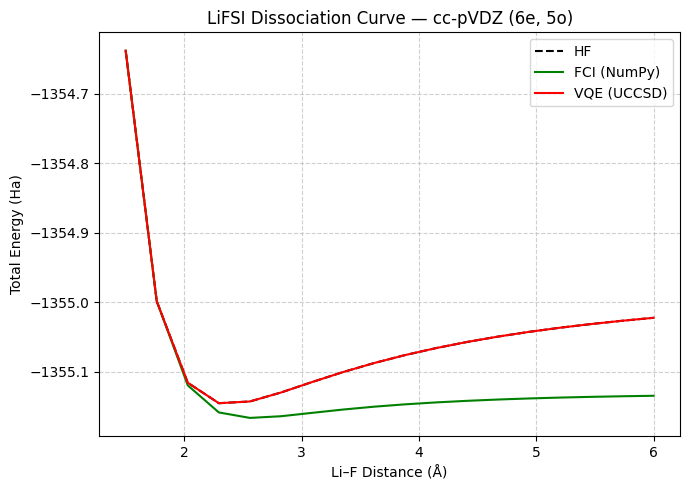

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# === Settings ===
basis = 'cc-pVDZ'
distances = np.linspace(1.5, 6.0, 18)

# === Storage ===
energies_hf = []
energies_fci = []
energies_vqe = []

# === Loop over distances ===
for d in distances:
    geom = (
        f"N 0.0000 0.0000 0.4842; "
        f"S 0.0000 1.4573 -0.2359; "
        f"O 1.2588 1.8319 -0.8267; "
        f"O -1.2588 1.8319 -0.8267; "
        f"F 0.0000 2.1851 1.3085; "
        f"S 0.0000 -1.4573 -0.2359; "
        f"O 1.2588 -1.8319 -0.8267; "
        f"O -1.2588 -1.8319 -0.8267; "
        f"F 0.0000 -2.1851 1.3085; "
        f"Li 0.0000 0.0000 {d:6.4f}"
    )

    # --- Build Qiskit Nature problem ---
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    problem = driver.run()

    # --- Freeze/Remove orbitals ---
    remove_orbs = list(range(49, problem.num_spatial_orbitals))
    fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=list(range(0, 41)) + remove_orbs)
    problem_red = fc.transform(problem)

    # --- Active space: 2 electrons in 2 orbitals (indices 4 and 5) ---
    ast = ActiveSpaceTransformer(num_electrons=6, num_spatial_orbitals=5, active_orbitals=[2, 3, 4, 5, 6])
    problem_act = ast.transform(problem_red)

    mapper = JordanWignerMapper()

    # --- HF ---
    energies_hf.append(problem_act.reference_energy)

    # --- FCI (NumPy exact eigensolver) ---
    fci_solver = GroundStateEigensolver(mapper, NumPyMinimumEigensolver())
    fci_result = fci_solver.solve(problem_act)
    energies_fci.append(fci_result.total_energies[0].real)

    # --- VQE with UCCSD ansatz ---
    init_state = HartreeFock(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper)
    ansatz = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)
    #ansatz = EfficientSU2(num_qubits=problem_act.num_spin_orbitals, reps=2)
    #ansatz = TwoLocal(num_qubits=problem_act.num_spin_orbitals,
                                     #rotation_blocks='ry', entanglement_blocks='cz',
                                     #reps=2, entanglement='full')

    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=6000), initial_point=[0.0] * ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    vqe_result = solver.solve(problem_act)
    energies_vqe.append(vqe_result.total_energies[0].real)

    # --- Report ---
    print(f"Li–F = {d:.2f} Å | HF = {energies_hf[-1]:.6f} | FCI = {energies_fci[-1]:.6f} | VQE = {energies_vqe[-1]:.6f}")

# === Plot: Absolute Energies ===
plt.figure(figsize=(7, 5))
plt.plot(distances, energies_hf, 'k--', label='HF')
plt.plot(distances, energies_fci, 'g-', label='FCI (NumPy)')
plt.plot(distances, energies_vqe, 'r-', label='VQE (UCCSD)')

plt.xlabel('Li–F Distance (Å)')
plt.ylabel('Total Energy (Ha)')
plt.title('LiFSI Dissociation Curve — cc-pVDZ (6e, 5o)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig("NaPF6_ccpvdz_dissociation_HF_VQE_FCI.png", dpi=600)
plt.show()

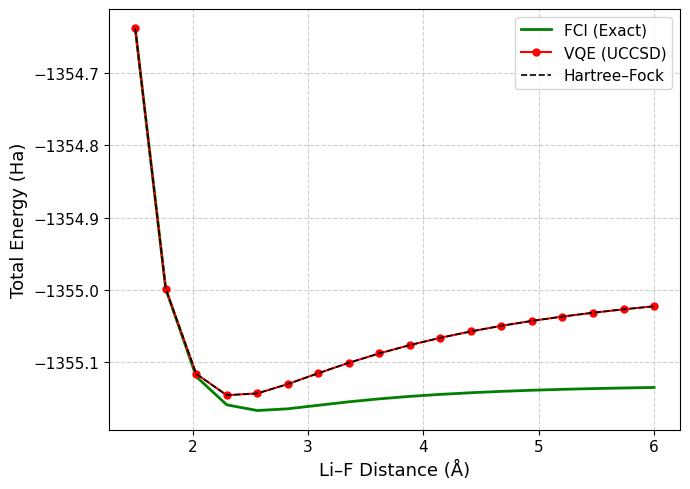

In [3]:
# === Plot: Publication-Quality Dissociation Curve ===
plt.figure(figsize=(7, 5))

# Plot lines
plt.plot(distances, energies_fci, 'g-', label='FCI (Exact)', linewidth=2.0)
plt.plot(distances, energies_vqe, 'ro-', label='VQE (UCCSD)', markersize=5, linewidth=1.5)
plt.plot(distances, energies_hf, 'k--', label='Hartree–Fock', linewidth=1.2)

# Axes
plt.xlabel('Li–F Distance (Å)', fontsize=13)
plt.ylabel('Total Energy (Ha)', fontsize=13)
#plt.title('NaPF₆ Dissociation Curve (cc-pVDZ, 2e in 2o)', fontsize=14)

# Grid, legend, layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()

# Save high-res image
plt.savefig("LiFSI_dissociation_VQE_vs_FCI_UCCSD.jpg", dpi=600)
plt.show()

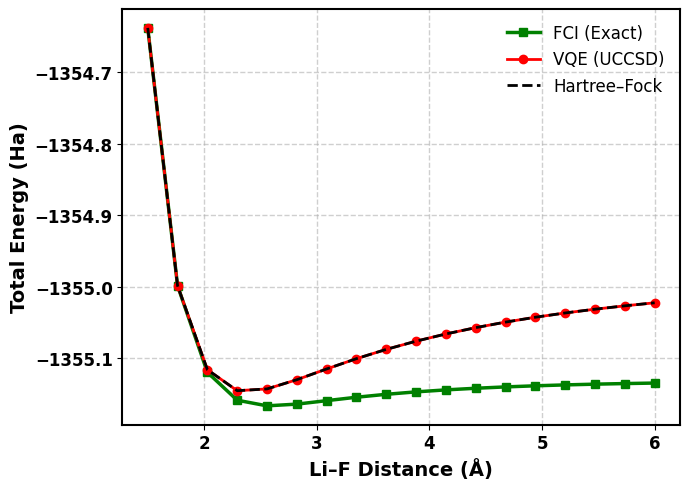

In [4]:
import matplotlib.pyplot as plt

# === Create Figure ===
plt.figure(figsize=(7, 5))

# === Plot Lines with Enhanced Style ===
plt.plot(distances, energies_fci, color='green', linestyle='-', label='FCI (Exact)', linewidth=2.5, marker='s', markersize=6)
plt.plot(distances, energies_vqe, color='red', linestyle='-', marker='o', label='VQE (UCCSD)', linewidth=2, markersize=6)
plt.plot(distances, energies_hf, color='black', linestyle='--', label='Hartree–Fock', linewidth=2)

# === Axis Labels (Bold + Readable Font) ===
plt.xlabel('Li–F Distance (Å)', fontsize=14, fontweight='bold')
plt.ylabel('Total Energy (Ha)', fontsize=14, fontweight='bold')

# === Axis Tick Styling ===
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# === Grid and Legend ===
plt.grid(True, linestyle='--', linewidth=1, alpha=0.6)
plt.legend(fontsize=12, frameon=False)

# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# === Final Layout and Save ===
plt.tight_layout()
plt.savefig("LiFSI_dissociation_VQE_vs_FCI_UCCSD.jpg", dpi=600, bbox_inches='tight')  # .tiff recommended for print
plt.show()


converged SCF energy = -1354.63837462962
CASCI E = -1354.63837864597  E(CI) = -7.11291002655526  S^2 = 0.0000000
Li–F = 1.50 Å | HF = -1354.638375 | FCI = -1354.638379 | VQE = -1354.638379 | CASCI = -1354.638379
converged SCF energy = -1354.99853813115
CASCI E = -1354.99854061760  E(CI) = -7.16405969314565  S^2 = 0.0000000
Li–F = 1.76 Å | HF = -1354.998538 | FCI = -1354.998541 | VQE = -1354.998541 | CASCI = -1354.998541
converged SCF energy = -1355.11584255934
CASCI E = -1355.11584531257  E(CI) = -6.83866896777067  S^2 = 0.0000000
Li–F = 2.03 Å | HF = -1355.115843 | FCI = -1355.119604 | VQE = -1355.115845 | CASCI = -1355.115845
converged SCF energy = -1355.14525667687
CASCI E = -1355.14525948501  E(CI) = -7.09353472446764  S^2 = 0.0000000
Li–F = 2.29 Å | HF = -1355.145257 | FCI = -1355.158517 | VQE = -1355.145259 | CASCI = -1355.145259
converged SCF energy = -1355.14275566226
CASCI E = -1355.14275845567  E(CI) = -7.06058840605078  S^2 = 0.0000000
Li–F = 2.56 Å | HF = -1355.142756 | FCI

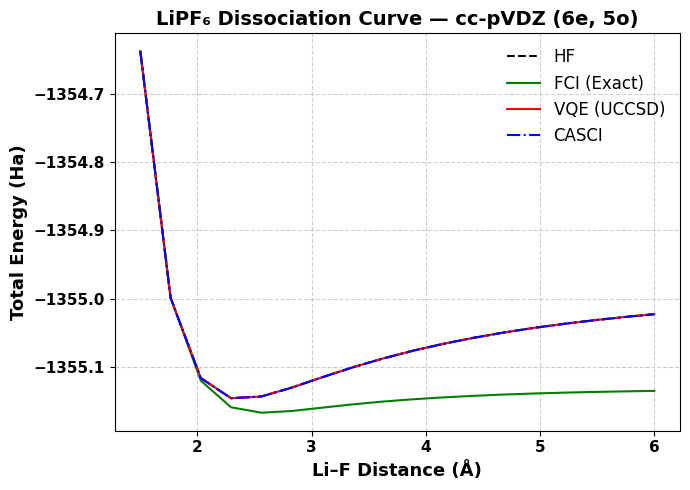

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# === Additional imports for CASCI ===
import pyscf 
from pyscf import gto, scf, mcscf
from pyscf.lib import logger

# === Settings ===
basis = 'cc-pVDZ'
distances = np.linspace(1.5, 6.0, 18)

# === Storage ===
energies_hf = []
energies_fci = []
energies_vqe = []
energies_casci = []

# === Loop over distances ===
for d in distances:
    # --- Geometry for Qiskit and PySCF ---
    geom_str = (
        f"N 0.0000 0.0000 0.4842; "
        f"S 0.0000 1.4573 -0.2359; "
        f"O 1.2588 1.8319 -0.8267; "
        f"O -1.2588 1.8319 -0.8267; "
        f"F 0.0000 2.1851 1.3085; "
        f"S 0.0000 -1.4573 -0.2359; "
        f"O 1.2588 -1.8319 -0.8267; "
        f"O -1.2588 -1.8319 -0.8267; "
        f"F 0.0000 -2.1851 1.3085; "
        f"Li 0.0000 0.0000 {d:6.4f}"
    )

    # --- Qiskit Driver ---
    driver = PySCFDriver(atom=geom_str, basis=basis, unit=DistanceUnit.ANGSTROM)
    problem = driver.run()

    # --- Freeze and reduce orbitals ---
    remove_orbs = list(range(49, problem.num_spatial_orbitals))
    fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=list(range(0, 41)) + remove_orbs)
    problem_red = fc.transform(problem)

    # --- Active space: 6 electrons in 5 orbitals ---
    ast = ActiveSpaceTransformer(num_electrons=6, num_spatial_orbitals=5, active_orbitals=[2, 3, 4, 5, 6])
    problem_act = ast.transform(problem_red)

    mapper = JordanWignerMapper()

    # --- HF ---
    energies_hf.append(problem_act.reference_energy)

    # --- FCI (exact) ---
    fci_solver = GroundStateEigensolver(mapper, NumPyMinimumEigensolver())
    fci_result = fci_solver.solve(problem_act)
    energies_fci.append(fci_result.total_energies[0].real)

    # --- VQE ---
    init_state = HartreeFock(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper)
    ansatz = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)
    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=6000), initial_point=[0.0] * ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    vqe_result = solver.solve(problem_act)
    energies_vqe.append(vqe_result.total_energies[0].real)

    # === CASCI Energy ===
    mol = pyscf.gto.Mole()
    mol.atom = geom_str
    mol.basis = basis
    mol.spin = 0
    mol.charge = 0
    mol.unit = 'Angstrom'
    mol.build()

    mf = pyscf.scf.RHF(mol).run()
    mo_occ = mf.mo_occ
    homo_idx = int(np.max(np.where(mo_occ > 0)))
    lumo_idx = homo_idx + 1

    active_orbs = list(range(max(homo_idx - 2, 0), min(homo_idx + 3, mf.mo_coeff.shape[1])))
    n_active_elec = int(np.sum(mo_occ[active_orbs]))
    nelec = ((n_active_elec + mol.spin) // 2, (n_active_elec - mol.spin) // 2)

    cas = mcscf.CASCI(mf, len(active_orbs), nelec)
    mo = cas.sort_mo(active_orbs)
    cas.kernel()
    energies_casci.append(cas.e_tot)

    # --- Report ---
    print(f"Li–F = {d:.2f} Å | HF = {energies_hf[-1]:.6f} | FCI = {energies_fci[-1]:.6f} | VQE = {energies_vqe[-1]:.6f} | CASCI = {energies_casci[-1]:.6f}")

# === Plot: Absolute Energies ===
plt.figure(figsize=(7, 5))
plt.plot(distances, energies_hf, 'k--', label='HF')
plt.plot(distances, energies_fci, 'g-', label='FCI (Exact)')
plt.plot(distances, energies_vqe, 'r-', label='VQE (UCCSD)')
plt.plot(distances, energies_casci, 'b-.', label='CASCI')

plt.xlabel('Li–F Distance (Å)', fontsize=13, fontweight='bold')
plt.ylabel('Total Energy (Ha)', fontsize=13, fontweight='bold')
plt.title('LiPF₆ Dissociation Curve — cc-pVDZ (6e, 5o)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, frameon=False)
plt.tight_layout()

# Save plot if needed
# plt.savefig("LiPF6_dissociation_HF_VQE_FCI_CASCI.png", dpi=600)
plt.show()

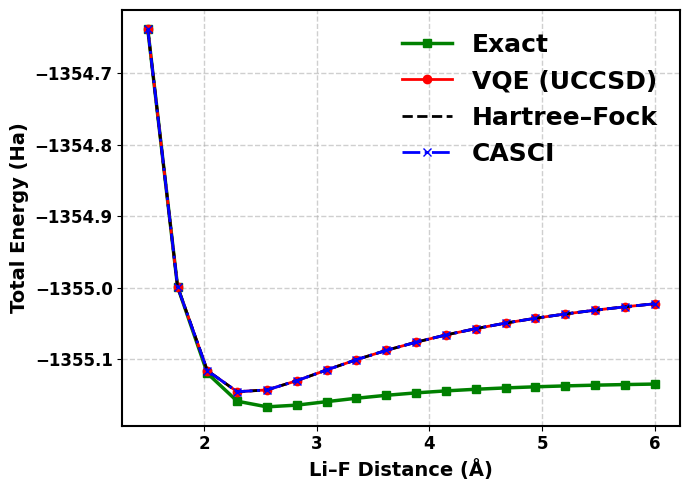

In [9]:
import matplotlib.pyplot as plt

# === Create Figure ===
plt.figure(figsize=(7, 5))

# === Plot Lines with Enhanced Style ===
plt.plot(distances, energies_fci, color='green', linestyle='-', label='Exact', linewidth=2.5, marker='s', markersize=6)
plt.plot(distances, energies_vqe, color='red', linestyle='-', marker='o', label='VQE (UCCSD)', linewidth=2, markersize=6)
plt.plot(distances, energies_hf, color='black', linestyle='--', label='Hartree–Fock', linewidth=2)
plt.plot(distances, energies_casci, color='blue', linestyle='-.', label='CASCI', linewidth=2, marker='x', markersize=6)

# === Axis Labels (Bold + Readable Font) ===
plt.xlabel('Li–F Distance (Å)', fontsize=14, fontweight='bold')
plt.ylabel('Total Energy (Ha)', fontsize=14, fontweight='bold')

# === Axis Tick Styling ===
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# === Grid and Legend ===
plt.grid(True, linestyle='--', linewidth=1, alpha=0.6)
plt.legend(prop=FontProperties(weight='bold', size=18), frameon=False)

# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# === Final Layout and Save ===
plt.tight_layout()
plt.savefig("LiFSI_dissociation_VQE_vs_FCI_UCCSD.jpg", dpi=600, bbox_inches='tight')  # .tiff recommended for print
plt.show()


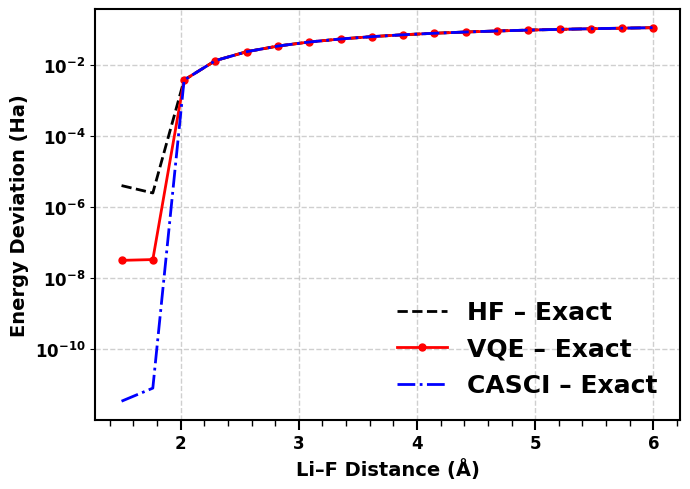

In [7]:
# === Compute Energy Deviations from FCI ===
from matplotlib.font_manager import FontProperties
import matplotlib.ticker as ticker

errors_hf = [abs(e_hf - e_fci) for e_hf, e_fci in zip(energies_hf, energies_fci)]
errors_vqe = [abs(e_vqe - e_fci) for e_vqe, e_fci in zip(energies_vqe, energies_fci)]
errors_casci = [abs(e_casci - e_fci) for e_casci, e_fci in zip(energies_casci, energies_fci)]

# === Plot: Energy Deviation from FCI ===
plt.figure(figsize=(7, 5))

plt.plot(distances, errors_hf, 'k--', label='HF – Exact', linewidth=2)
plt.plot(distances, errors_vqe, 'r-o', label='VQE – Exact', linewidth=2, markersize=5)
plt.plot(distances, errors_casci, 'b-.', label='CASCI – Exact', linewidth=2, markersize=5)

plt.xlabel('Li–F Distance (Å)', fontsize=14, fontweight='bold')
plt.ylabel('Energy Deviation (Ha)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# Log scale for better error visibility
plt.yscale('log')
plt.grid(True, linestyle='--', linewidth=1, alpha=0.6)
plt.legend(prop=FontProperties(weight='bold', size=18), frameon=False,)

#  Minor ticks on x-axis
ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis='x', which='minor', length=4, width=1)
ax.tick_params(axis='x', which='major', length=7, width=1.5)

# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

#plt.title('Deviation from FCI — LiPF₆ cc-pVDZ (6e, 5o)', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save high-resolution image if needed
plt.savefig("LiFSI_energy_deviation_FCI.jpg", dpi=600, bbox_inches='tight')

plt.show()

In [2]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM, EvaluationRule
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# ──────────────────────────────────────────────────────────────────────────────
# 1.  Geometry
# ──────────────────────────────────────────────────────────────────────────────
lifsi_geometry = (
    "N 0.0000 0.0000 0.4842; "
    "S 0.0000 1.4573 -0.2359; "
    "O 1.2588 1.8319 -0.8267; "
    "O -1.2588 1.8319 -0.8267; "
    "F 0.0000 2.1851 1.3085; "
    "S 0.0000 -1.4573 -0.2359; "
    "O 1.2588 -1.8319 -0.8267; "
    "O -1.2588 -1.8319 -0.8267; "
    "F 0.0000 -2.1851 1.3085; "
    "Li 0.0000 0.0000 2.3536"
)

driver = PySCFDriver(atom=lifsi_geometry,
                     basis='cc-pVDZ',
                     charge=0,
                     spin=0,
                     unit=DistanceUnit.ANGSTROM)
problem = driver.run()

print("── Original HF problem ─────────────────────────")
print("Spatial orbitals :", problem.num_spatial_orbitals)
print("Spin  orbitals   :", problem.num_spin_orbitals)
na, nb = problem.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 2.  Freeze‑core + trim high‑energy virtuals
# ──────────────────────────────────────────────────────────────────────────────
freeze_core     = list(range(0, 41))
remove_orbitals = list(range(49, problem.num_spatial_orbitals))

fc = FreezeCoreTransformer(freeze_core=False,
                           remove_orbitals=remove_orbitals+freeze_core)
problem_red = fc.transform(problem)

all_orbs     = set(range(problem.num_spatial_orbitals))
frozen_orbs  = set(freeze_core)
removed_orbs = set(remove_orbitals)
kept_fc      = sorted(all_orbs - frozen_orbs - removed_orbs)

print("── After FreezeCoreTransformer ────────────────")
print("Frozen orbitals   :", sorted(freeze_core))
print("Removed virtuals  :", sorted(remove_orbitals))
print("Kept orbitals     :", kept_fc)
print("Spatial orbitals  :", problem_red.num_spatial_orbitals, "\n")
na, nb = problem_red.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 3.  Active‑space reduction (6 e⁻ in 5 MOs)
# ──────────────────────────────────────────────────────────────────────────────
active_orbs_reduced = [3, 4, 5]
ast = ActiveSpaceTransformer(
    num_electrons=4,
    num_spatial_orbitals=3,
    active_orbitals=active_orbs_reduced
)
problem_act = ast.transform(problem_red)

active_original = [kept_fc[i] for i in active_orbs_reduced]

print("── Active space ───────────────────────────────")
print("Active orbitals (re‑indexed) :", active_orbs_reduced)
print("Active orbitals (original HF):", active_original)
print("Spatial orbitals              :", problem_act.num_spatial_orbitals)
na, nb = problem_act.num_particles
print(f"Electrons                     : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 4.  Qubit mapping, ansatz, VQE + QEOM for excited states
# ──────────────────────────────────────────────────────────────────────────────
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(problem_act.second_q_ops()[0])

init_state = HartreeFock(problem_act.num_spatial_orbitals,
                         problem_act.num_particles, mapper)
ansatz = UCCSD(problem_act.num_spatial_orbitals,
               problem_act.num_particles, mapper,
               initial_state=init_state)

vqe = VQE(estimator=Estimator(),
          ansatz=ansatz,
          optimizer=COBYLA(maxiter=10000))
vqe.initial_point = [0.0] * ansatz.num_parameters

gs_solver = GroundStateEigensolver(mapper, vqe)

# --- QEOM for excited states ---
qeom_solver = QEOM(gs_solver, Estimator(), "sd", EvaluationRule.ALL)
qeom_result = qeom_solver.solve(problem_act)

print("── VQE + QEOM results ────────────────────────────────")
hartree_to_ev = 27.2114
energies = [e.real for e in qeom_result.total_energies]
ground = energies[0]
for i, e in enumerate(energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_e = e - ground if i > 0 else 0
    print(f"{label} state: {e:.6f} Ha", end="")
    if i > 0:
        print(f"   ΔE = {delta_e:.6f} Ha ≈ {delta_e*hartree_to_ev:.2f} eV")
    else:
        print()

── Original HF problem ─────────────────────────
Spatial orbitals : 148
Spin  orbitals   : 296
Electrons        : 92 (46 α, 46 β)

── After FreezeCoreTransformer ────────────────
Frozen orbitals   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
Removed virtuals  : [49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147]
Kept orbitals     : [41, 42, 43, 44, 45, 46, 47, 48]
Spatial orbitals  : 8 

Electrons        : 10 (5 α, 5 β)

── Active space ───────────────────────────────
Active orbitals (re‑in